In [1]:
from typing import TypedDict, List, Dict, Any, Optional
from uuid import uuid4
from datetime import datetime


In [2]:
class ClinicalState(TypedDict):
    # Input
    input_data: Dict[str, Any]

    # Agent outputs
    patient_profile: Dict[str, Any]
    data_quality_flags: List[str]

    clinical_insights: Dict[str, Any]
    risk_assessment: Dict[str, Any]
    recommendations: Dict[str, Any]
    explanation: Dict[str, Any]

    # Safety & final
    approval_required: bool
    final_output: Dict[str, Any]
    audit_log: Dict[str, Any]


In [4]:
import os
import google.generativeai as genai

genai.configure(api_key=os.getenv("GEMINI_API_KEY"))

def gemini_llm(system_prompt: str, user_payload: Dict[str, Any]) -> Dict[str, Any]:
    model = genai.GenerativeModel(
        model_name="models/gemini-2.5-flash",
        system_instruction=system_prompt
    )

    response = model.generate_content(
        contents=[{"role": "user", "parts": [str(user_payload)]}],
        generation_config={
            "temperature": 0.2,
            "response_mime_type": "application/json"
        }
    )

    return eval(response.text)  # Safe ONLY because Gemini returns strict JSON


In [5]:
def intake_agent(state: ClinicalState) -> ClinicalState:
    system_prompt = """
    You are a clinical data normalization agent.
    Validate input, normalize vitals, flag missing or abnormal data.
    Do not diagnose. Return strict JSON.
    """

    output = gemini_llm(system_prompt, state["input_data"])

    state["patient_profile"] = output.get("patient_profile", {})
    state["data_quality_flags"] = output.get("data_quality_flags", [])

    return state


In [6]:
def clinical_knowledge_agent(state: ClinicalState) -> ClinicalState:
    system_prompt = """
    You are a clinical knowledge agent.
    Identify possible clinical concerns without diagnosis.
    Use probabilistic language only.
    """

    output = gemini_llm(system_prompt, state["patient_profile"])
    state["clinical_insights"] = output
    return state


In [7]:
def risk_agent(state: ClinicalState) -> ClinicalState:
    system_prompt = """
    You are a risk stratification agent.
    Classify patient risk as LOW, MODERATE, or HIGH.
    Justify clearly. Be conservative.
    """

    payload = {
        "profile": state["patient_profile"],
        "insights": state["clinical_insights"]
    }

    output = gemini_llm(system_prompt, payload)
    state["risk_assessment"] = output

    state["approval_required"] = output.get("risk_level") == "HIGH"
    return state


In [8]:
def recommendation_agent(state: ClinicalState) -> ClinicalState:
    system_prompt = """
    You are a clinical decision-support agent.
    Suggest diagnostic tests and care pathways only.
    No treatment. Include disclaimer.
    """

    payload = {
        "risk": state["risk_assessment"],
        "insights": state["clinical_insights"]
    }

    output = gemini_llm(system_prompt, payload)
    state["recommendations"] = output
    return state


In [9]:
def explainability_agent(state: ClinicalState) -> ClinicalState:
    system_prompt = """
    You explain clinical AI reasoning clearly and transparently.
    No hallucinations. No diagnosis.
    """

    output = gemini_llm(system_prompt, state)
    state["explanation"] = output
    return state


In [10]:
def safety_agent(state: ClinicalState) -> ClinicalState:
    audit = {
        "request_id": str(uuid4()),
        "timestamp": datetime.utcnow().isoformat(),
        "agent_chain": [
            "intake",
            "clinical_knowledge",
            "risk",
            "recommendation",
            "explainability",
            "safety"
        ]
    }

    state["audit_log"] = audit

    state["final_output"] = {
        "risk_summary": state["risk_assessment"],
        "clinical_insights": state["clinical_insights"],
        "recommendations": state["recommendations"],
        "explanation": state["explanation"],
        "approval_required": state["approval_required"],
        "audit_log": audit
    }

    return state


In [11]:
from langgraph.graph import StateGraph

graph = StateGraph(ClinicalState)

graph.add_node("intake", intake_agent)
graph.add_node("knowledge", clinical_knowledge_agent)
graph.add_node("risk", risk_agent)
graph.add_node("recommendation", recommendation_agent)
graph.add_node("explainability", explainability_agent)
graph.add_node("safety", safety_agent)

graph.set_entry_point("intake")

graph.add_edge("intake", "knowledge")
graph.add_edge("knowledge", "risk")
graph.add_edge("risk", "recommendation")
graph.add_edge("recommendation", "explainability")
graph.add_edge("explainability", "safety")

clinical_graph = graph.compile()


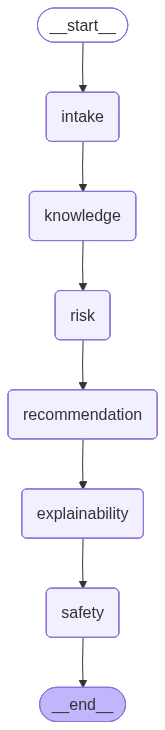

In [13]:
graph.compile()

In [14]:
if __name__ == "__main__":
    input_data = {
        "patient_id": "P001",
        "age": 65,
        "gender": "male",
        "symptoms": "shortness of breath and chest discomfort",
        "vitals": {
            "heart_rate": 110,
            "blood_pressure": "150/95",
            "temperature": 37.8,
            "oxygen_saturation": 91
        }
    }

    state: ClinicalState = {"input_data": input_data}
    result = clinical_graph.invoke(state)

    print(result["final_output"])


{'risk_summary': {'risk_classification': 'LOW', 'justification': 'No clinical information or patient profile was provided to assess potential risks. Therefore, in the absence of any data suggesting concerns, the risk is classified as LOW by default.'}, 'clinical_insights': {'message': 'No input provided to identify clinical concerns.', 'possible_clinical_concerns': []}, 'recommendations': {'diagnostic_tests': 'No specific diagnostic tests can be recommended without clinical information or patient profile.', 'care_pathways': 'No specific care pathways can be suggested without clinical information or patient profile.', 'disclaimer': 'This information is for educational purposes only and not intended as medical advice. Always consult with a qualified healthcare professional for diagnosis and treatment.'}, 'explanation': {'ai_reasoning_explanation': {'input_data_received': {'description': 'The AI successfully received and parsed the following patient information:', 'details': {'patient_id'

C:\Users\Anonymous\AppData\Local\Temp\ipykernel_5908\3959643529.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
